## Imports

In [11]:
import pandas as pd
import os
from pathlib import Path
from reload_recursive import reload_recursive
from tqdm.notebook import tqdm

from helpers.parallel import BetterPool

from collections import defaultdict

import scripts.compile_run_metrics
import helpers.utils
import scripts.inference
from IPython.display import clear_output

In [12]:
reload_recursive(scripts.compile_run_metrics)
#TODO Thi
from scripts.compile_run_metrics import EXPERIMENT_KEYS

reload_recursive(scripts.inference)
from scripts.inference import uncrop_predictions

import analysis.image
reload_recursive(analysis.image)
from analysis.image import lesion_analysis as lesion_dx
from analysis.image import classify

reload_recursive(helpers.utils)
from helpers.utils import dice_score, get_prl_indices

import helpers.shell_interface
reload_recursive(helpers.shell_interface)
from helpers.shell_interface import open_itksnap_workspace_cmd

import core.dataset
reload_recursive(core.dataset)
from core.dataset import Dataset

import core.experiment
reload_recursive(core.experiment)
from core.experiment import Experiment
from loguru import logger

import scripts
reload_recursive(scripts)
# from scripts import lesion_diagnostics as lesion_dx
from scripts.compile_run_metrics import load_or_cache_run

In [13]:
analysis_dir = Path("/home/srs-9/Projects/prl_project/analysis")

## Analysis

### Inference Set 1

In [14]:
train_dataset_name = "roi_train2"
train_dataset = Dataset(train_dataset_name)

experiment_key, run_name = "stage6", "run1"
experiment_name = f"{EXPERIMENT_KEYS[experiment_key]}/{run_name}"
experiment = Experiment.from_run_dir(experiment_name, train_dataset)
experiment_name = experiment.name.replace("/", "_")


expand_xy: int = experiment.preprocess_config.expand_xy
expand_z: int = experiment.preprocess_config.expand_z
images: tuple[str, ...] = experiment.preprocess_config.images

train_radiomic_df = pd.read_csv(
    analysis_dir / f"prl_image_stats-{train_dataset_name}_{experiment_name}.csv"
)

inference_dataset = Dataset("inference_dataset")
datafile_name = f"prl_{inference_dataset.name}_image_stats-{train_dataset_name}_{experiment_name}.csv"
inf_radiomics_df = pd.read_csv(analysis_dir/datafile_name)

full_inference_dataset = Dataset("full_inference_dataset")
datafile_name = f"prl_{full_inference_dataset.name}_image_stats-{train_dataset_name}_{experiment_name}.csv"
full_inf_radiomics_df = pd.read_csv(analysis_dir/datafile_name)

# these are already filtered for "has_iron_infer"
large_train_df = pd.concat([train_radiomic_df, inf_radiomics_df], axis=0, ignore_index=True)

In [15]:
len(train_dataset.prl_df)

76


--- Test set ---
              precision    recall  f1-score   support

      Lesion       0.91      0.84      0.87        99
         PRL       0.67      0.80      0.73        40

    accuracy                           0.83       139
   macro avg       0.79      0.82      0.80       139
weighted avg       0.84      0.83      0.83       139

ROC-AUC: 0.880


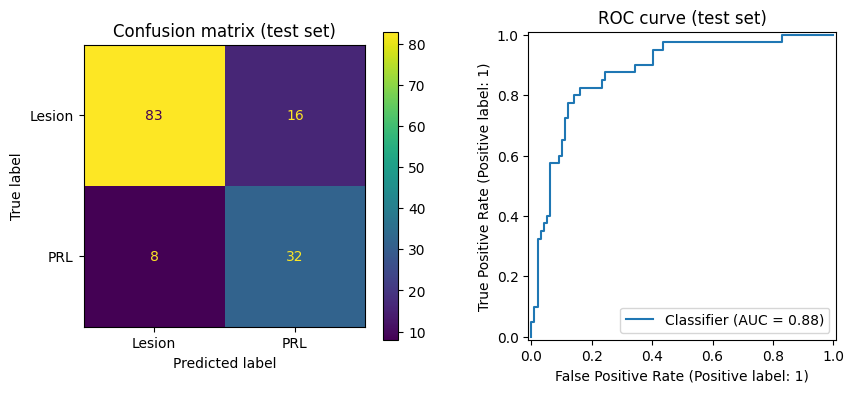

In [16]:
X_train, X_test, y_train, y_test = classify.prepare_data(large_train_df)
model = classify.train_model(X_train, y_train)
fig, axes = classify.evaluate_model(model, X_test, y_test, display=True, to_print=True, return_fig=True)

In [17]:
fig.savefig("classifier pereformance.png", dpi=600, transparent=True)

In [18]:
# Go down as far as it will allow on test size to create the model I will apply to the other full dataset
X_train, _, y_train, _ = classify.prepare_data(large_train_df, test_size=0)

# ik this is double dipping, but its just so I can get volumes of rim, not to evaluate model performance
all_subject_radiomics = pd.concat([large_train_df, full_inf_radiomics_df], axis=0, ignore_index=True)
_, X_test, _, y_test = classify.prepare_data(all_subject_radiomics, test_size=1)

model = classify.train_model(X_train, y_train)
y_pred, y_prob = classify.evaluate_model(model, X_test, y_test)
all_subject_radiomics['isPRL_infer'] = y_pred
all_subject_radiomics['isPRL_prob'] = y_prob

In [19]:
all_subject_radiomics.groupby("subid")['isPRL_infer'].sum()

subid
1001    0
1002    4
1003    0
1004    0
1005    2
       ..
3016    0
3017    0
3021    0
3023    1
3028    0
Name: isPRL_infer, Length: 393, dtype: int64

In [20]:
final_rim_volumes = all_subject_radiomics[all_subject_radiomics['isPRL_infer']==1].groupby("subid")['rim_volume_infer'].sum()
final_lesion_volumes = all_subject_radiomics[all_subject_radiomics['isPRL_infer']==1].groupby("subid")['lesion_volume_infer'].sum()

df = full_inference_dataset.prl_df.copy()
df['rim_volume'] = 0.0
df.loc[final_rim_volumes.index, 'rim_volume'] = final_rim_volumes

df['nPRL_infer'] = 0
df['nPRL_infer'] = all_subject_radiomics.groupby("subid")['isPRL_infer'].sum()

In [21]:
df.loc[1126, :]

PRL_possible              2
PRL_probable              3
PRL_definite             11
PRL                    14.0
date_mri           20170609
Total PRL              14.0
PRL1_label             23.0
PRL2_label              5.0
PRL3_label             18.0
PRL4_label             15.0
PRL5_label              6.0
PRL6_label             13.0
PRL7_label              4.0
PRL8_label              7.0
PRL9_label              1.0
PRL10_label             2.0
PRL11_label             2.0
PRL12_label             2.0
PRL13_label             2.0
PRL14_label             2.0
PRL15_label             1.0
PRL16_label             9.0
PRL17_label             NaN
PRL18_label             NaN
PRL19_label             NaN
PRL20_label             NaN
confidence.0       definite
confidence.1       definite
confidence.2       definite
confidence.3       possible
confidence.4       definite
confidence.5       probable
confidence.6       definite
confidence.7       probable
confidence.8       definite
confidence.9       d

[Text(0, 0, ''),
 Text(1, 0, ''),
 Text(2, 0, ''),
 Text(3, 0, ''),
 Text(4, 0, ''),
 Text(5, 0, ''),
 Text(6, 0, ''),
 Text(7, 0, ''),
 Text(8, 0, ''),
 Text(9, 0, ''),
 Text(10, 0, ''),
 Text(11, 0, ''),
 Text(12, 0, ''),
 Text(13, 0, '')]

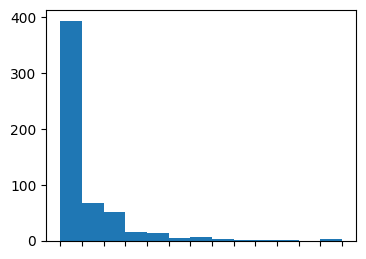

In [43]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, figsize=(4,3))
ax.hist(df['PRL'], bins=np.arange(0, 14, 1))
# plt.axes(visible=False)
# ax.set_yticklabels([])
ax.set_xticks(np.arange(0, 14, 1))
ax.set_xticklabels([])
# fig.savefig("PRL hist.png", transparent=True, dpi=600)

In [11]:
all_subject_radiomics

,subid,lesion_index,case_type,has_iron_infer,rim_voxels_infer,rim_volume_infer,rim_hull_volume_infer,rim_sphere_radius_infer,lesion_voxels_infer,lesion_volume_infer,...,pca_sphericity,pca_planarity,pca_linearity,mean_radius,std_radius,min_radius,max_radius,radial_cv,isPRL_infer,isPRL_prob
0,1033,2,PRL,True,304,155.647610,263.593991,6.260826,530,271.359300,...,0.563239,0.235150,0.201611,4.632045,1.231196,1.825990,7.664771,0.265800,1,0.883458
1,1033,1,Lesion,True,188,96.255760,243.711375,6.075049,644,329.727170,...,0.607194,0.115690,0.277116,4.474779,1.096146,2.176598,8.306837,0.244961,1,0.800010
2,1074,3,PRL,True,197,100.864380,141.909868,6.400752,276,141.312530,...,0.534251,0.139800,0.325950,3.816908,1.067341,0.549678,7.825353,0.279635,1,0.714015
3,1074,1,PRL,True,252,129.024490,159.488601,4.470342,268,137.216520,...,0.766027,0.117895,0.116078,3.881663,0.735932,1.896693,5.601359,0.189592,1,0.943135
4,1074,2,Lesion,True,18,9.216035,2.389342,2.469522,558,285.697080,...,0.210506,0.355478,0.434016,1.542056,0.642017,0.566558,3.053029,0.416338,0,0.091187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,3021,79,NaN,True,1,0.512002,NaN,0.000000,49,25.088095,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0,0.069449
2189,3028,1,NaN,True,318,162.816090,74438.948604,67.915074,28959,14827.016000,...,0.375684,0.305151,0.319166,37.973837,18.402679,10.187651,102.025688,0.484615,0,0.000127
2190,3028,3,NaN,True,53,27.136013,124.501395,14.423791,3214,1645.568800,...,0.406618,0.150507,0.442875,3.168959,2.450302,0.323518,18.848226,0.773220,0,0.133278
2191,3028,2,NaN,True,142,72.704040,41641.151143,53.861621,26672,13656.071000,...,0.268530,0.173834,0.557636,32.683382,15.532906,10.422283,71.731925,0.475254,0,0.005578


In [33]:
df['nPRL_diff'] = all_subject_radiomics.groupby("subid")['isPRL_infer'].sum() - all_subject_radiomics.groupby("subid")['has_iron_infer'].sum()

In [35]:
df.sort_values(by="nPRL_diff")

,PRL_possible,PRL_probable,PRL_definite,PRL,date_mri,Total PRL,PRL1_label,PRL2_label,PRL3_label,PRL4_label,...,confidence.13,confidence.14,confidence.15,confidence.16,confidence.17,confidence.18,confidence.19,rim_volume,nPRL_infer,nPRL_diff
subid,,,,,,,,,,,,,,,,,,,,,
1239,2,6,7,13.0,20170113,13.0,12.0,7.0,8.0,NaN,...,definite,probable,possible,NaN,NaN,NaN,NaN,1578.060132,10.0,-26.0
1405,4,2,4,6.0,20190407,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,773.638080,8.0,-19.0
1129,2,4,0,4.0,20200120,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1031.664088,11.0,-18.0
3021,0,0,0,0.0,20161117,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,-17.0
1346,1,0,0,0.0,20201012,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.349880,2.0,-14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3012,NaN,NaN,NaN,NaN,20200606,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
3014,NaN,NaN,NaN,NaN,20161214,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
3018,NaN,NaN,NaN,NaN,20170530,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN


In [24]:
from scripts.inference import uncrop_predictions

subid = 1126

which_dataset = inference_dataset
check = all_subject_radiomics.set_index(["subid", "lesion_index"])
subject_cases = check[check.index.get_level_values("subid")==subid]
valid_indices = subject_cases.loc[subject_cases['isPRL_infer']==1, :].index.get_level_values("lesion_index")
base_path = which_dataset.data_root
subject_dir = base_path / which_dataset.subject(subid).dir
expand_xy = experiment.preprocess_config.expand_xy
expand_z = experiment.preprocess_config.expand_z
images = experiment.preprocess_config.images
run_id = experiment.name.replace("/", "_")
suffix = "classed"

uncrop_predictions(subject_dir, expand_xy, expand_z, which_dataset.data_root, images, run_id, suffix=suffix, valid_indices=valid_indices)

2026-05-21 16:37:22.330 | INFO     | scripts.inference:uncrop_predictions:378 - Saved uncropped prediction: /media/smbshare/srs-9/prl_project/inference_data/sub1126-20170609/prl_inference_stage6_sweep_dicece_wts_run1classed.nii.gz


PosixPath('/media/smbshare/srs-9/prl_project/inference_data/sub1126-20170609/prl_inference_stage6_sweep_dicece_wts_run1classed.nii.gz')

In [29]:
experiment.name

'stage6_sweep_dicece_wts/run1'

In [10]:
df.to_csv(analysis_dir / "all_inferred_rim_volumes.csv")